In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
upload = files.upload()

Saving student_scores.csv to student_scores.csv


# EDA


In [ ]:
data = pd.read_csv('student_scores.csv')

In [ ]:
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [ ]:
data.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
data.isnull().sum()

,0
Hours,0
Scores,0


In [ ]:
data['Hours'].corr(data['Scores'])

np.float64(0.9761906560220887)

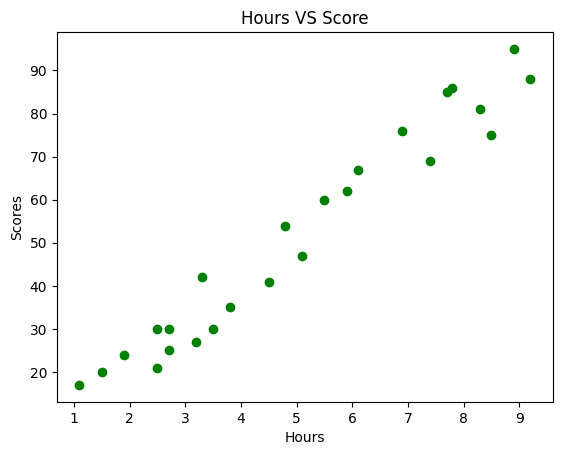

In [ ]:
plt.scatter(data['Hours'], data['Scores'], color='green')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.title('Hours VS Score')
plt.show()

# Preprocessing


In [ ]:
X = data[['Hours']]
y = data['Scores']

#Train the model



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(f"Intercept: {model.intercept_:,.2f}")
print(f"Coefficient: {model.coef_[0]:,.2f}")
print(f"Score = {model.intercept_:,.2f} + {model.coef_[0]:,.2f} x Hours")

Intercept: 2.83
Coefficient: 9.68
Score = 2.83 + 9.68 x Hours


#Evaluate

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE = {mse:.2f} \nMAE = {mae:.2f} \nR^2 = {r2:.2f} \nRMSE = {rmse:.2f}")

MSE = 18.94 
MAE = 3.92 
R^2 = 0.97 
RMSE = 4.35


#visualize regression

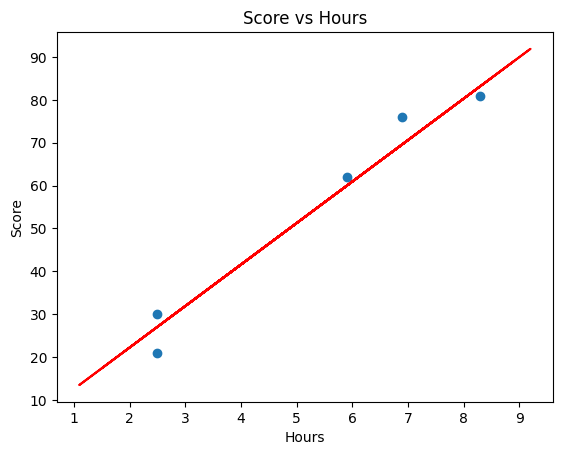

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X, model.predict(X), color = 'red')
plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Score vs Hours")
plt.show()

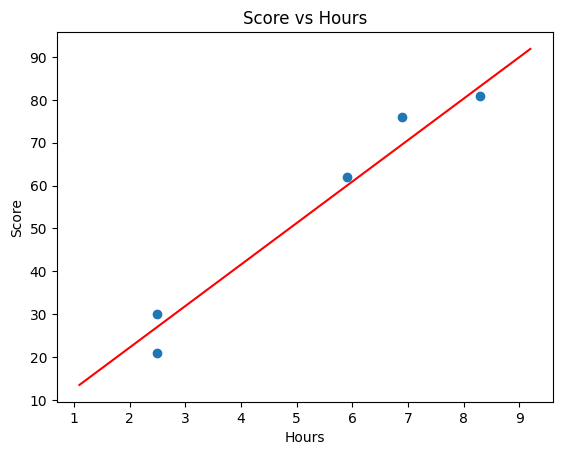

In [ ]:
X_line = np.linspace(X.min(), X.max(), 100)
X_lineDF = pd.DataFrame(X_line, columns = ['Hours'])
y_line = model.predict(X_lineDF)

plt.scatter(X_test, y_test)
plt.plot(X_line, y_line, color = 'red')
plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Score vs Hours")
plt.show()

#predict new score


In [ ]:
new_study_hour = pd.DataFrame([[8.5]], columns = ['Hours'])

prediction = model.predict(new_study_hour)
prediction

array([85.12455667])

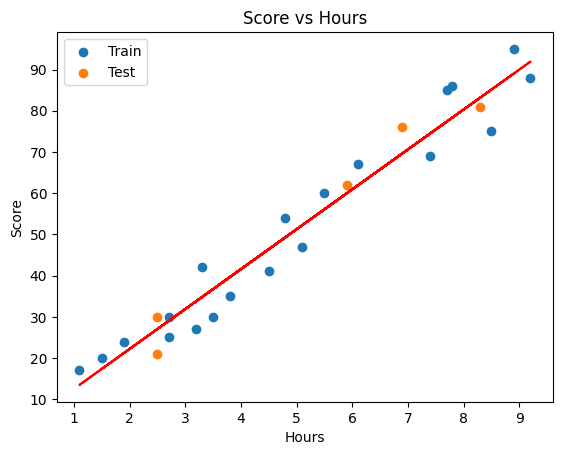

In [ ]:
plt.scatter(X_train, y_train, label='Train')
plt.scatter(X_test, y_test, label='Test')

plt.plot(X, model.predict(X), color='red')

plt.legend()
plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Score vs Hours")
plt.show()